Nothing changed below, as was from Kathrin
## Goerlitz Household PV Data

General information
- continuous daily data since 2005-05-18
- location: 02827 Goerlitz, Germany
- 3 parties on a single rooftop measured separately
- different number of panels:
    - S: 8 panels
    - W: 14 panels
    - H: 44 panels
- important: measurement device was exchanged (26.08.2021 to 27.08.2012)
    - here: counts start at zero again

Table Content
- relevant data "Gesamt-Leistung" = cumulative energy production
- other columns can be discarded and recalculated

## Preparations

In [1]:
# !pip install missingno

In [2]:
# load required packages
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
import pandas as pd
import numpy as np

from IPython.display import display

import sys
sys.path.insert(0, '..')
from models.tools import show_info, get_alerts, dump_missing, parse_xml, plot_correlation, drop_na_and_zeros, get_common_index, add_date_features, compute_importance

## Load data

In [3]:
# Read the csv
# Take only the cumusive data along with the date
# Refer to 
df_raw = pd.read_csv(
    "../data/households/Goerlitz/PV_Goerlitz_02827.csv",
    sep=";",
    thousands=",",
    usecols=[
        "Unnamed: 0",
        "S Gesamt-Leistung",
        "W Gesamt-Leistung",
        "H Gesamt-Leistung",
    ],
).rename(
    columns={
        "Unnamed: 0": "date",
        "S Gesamt-Leistung": "group1_pv",
        "W Gesamt-Leistung": "group2_pv",
        "H Gesamt-Leistung": "group3_pv",
    }
)
# Strip the date strings and convert them to `datetime`
df_raw["date"] = pd.to_datetime(df_raw["date"].str.strip(), format="%d.%m.%Y")
# Set date as the index
df_raw.set_index("date", inplace=True)
df_raw.shape

(6630, 3)

### General view - plot

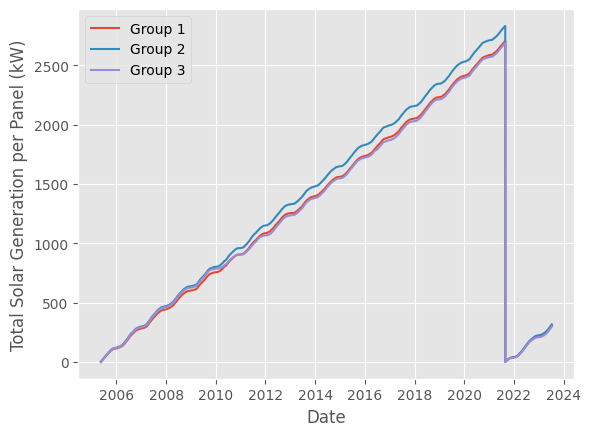

In [4]:
# Check how the data looks like
plt.style.use("ggplot")

sns.lineplot(x=df_raw.index, y=df_raw["group1_pv"]/8, label="Group 1")
sns.lineplot(x=df_raw.index, y=df_raw["group2_pv"]/14, label="Group 2")
sns.lineplot(x=df_raw.index, y=df_raw["group3_pv"]/44, label="Group 3")

plt.xlabel('Date')
plt.ylabel('Total Solar Generation per Panel (kW)')

plt.legend()
plt.show()

### Handle discontinuities

In [5]:
# Find the weird data
filter = (df_raw['group1_pv'].diff() < 0) | (df_raw['group2_pv'].diff() < 0) | (df_raw['group3_pv'].diff() < 0)
df_raw[filter]

,group1_pv,group2_pv,group3_pv
date,,,
2006-12-11,2231.1,4136.4,12765.4
2013-02-26,10046.5,18670.3,54532.7
2013-11-22,11135.7,20622.3,60534.8
2017-11-07,16368.8,30122.0,89071.5
2017-12-20,16408.5,30193.6,89281.6
2018-01-13,16422.3,30220.0,89355.8
2018-12-26,17860.0,32826.8,97396.0
2021-08-27,4.0,8.0,26.0


In [6]:
# Handle weirds

# Split the data df_raw into two parts
df1 = df_raw.query('index < "27.08.2021"')
df2 = df_raw.query('index >= "27.08.2021"')

# Calculate the daily production
df1 = df1.diff()
df2 = df2.diff()
print("The header of df1 is:")
display(df1.head())
print("The header of df2 is:")
display(df2.head())

# Fill the first row of nan with 0
df1.iloc[0] = 0
df2.iloc[0] = 0

# Output
print("The header after filling with 0 of df1 is:")
display(df1.head())
print("The header after filling with 0 of df2 is:")
display(df2.head())

# 
df = pd.concat([df1, df2], axis=0)
display(df.head())
display(df.index)

The header of df1 is:


,group1_pv,group2_pv,group3_pv
date,,,
2005-05-18,NaN,NaN,NaN
2005-05-19,6.2,11.4,32.2
2005-05-20,7.0,13.6,42.6
2005-05-21,6.2,11.4,36.2
2005-05-22,4.4,8.0,25.0


The header of df2 is:


,group1_pv,group2_pv,group3_pv
date,,,
2021-08-27,NaN,NaN,NaN
2021-08-28,3.0,5.0,14.0
2021-08-29,4.0,8.0,23.0
2021-08-30,3.0,6.0,18.0
2021-08-31,1.0,1.0,5.0


The header after filling with 0 of df1 is:


,group1_pv,group2_pv,group3_pv
date,,,
2005-05-18,0.0,0.0,0.0
2005-05-19,6.2,11.4,32.2
2005-05-20,7.0,13.6,42.6
2005-05-21,6.2,11.4,36.2
2005-05-22,4.4,8.0,25.0


The header after filling with 0 of df2 is:


,group1_pv,group2_pv,group3_pv
date,,,
2021-08-27,0.0,0.0,0.0
2021-08-28,3.0,5.0,14.0
2021-08-29,4.0,8.0,23.0
2021-08-30,3.0,6.0,18.0
2021-08-31,1.0,1.0,5.0


,group1_pv,group2_pv,group3_pv
date,,,
2005-05-18,0.0,0.0,0.0
2005-05-19,6.2,11.4,32.2
2005-05-20,7.0,13.6,42.6
2005-05-21,6.2,11.4,36.2
2005-05-22,4.4,8.0,25.0


DatetimeIndex(['2005-05-18', '2005-05-19', '2005-05-20', '2005-05-21',
               '2005-05-22', '2005-05-23', '2005-05-24', '2005-05-25',
               '2005-05-26', '2005-05-27',
               ...
               '2023-07-03', '2023-07-04', '2023-07-05', '2023-07-06',
               '2023-07-07', '2023-07-08', '2023-07-09', '2023-07-10',
               '2023-07-11', '2023-07-12'],
              dtype='datetime64[ns]', name='date', length=6630, freq=None)

In [7]:
# Find the weird data
filter = (df['group1_pv'] < 0) | (df['group2_pv'] < 0) | (df['group3_pv'] < 0)
df[filter]

,group1_pv,group2_pv,group3_pv
date,,,
2006-12-11,0.0,-0.1,0.2
2013-02-26,0.3,0.4,-2.2
2013-11-22,0.1,-0.1,1.6
2017-11-07,-0.1,0.3,0.9
2017-12-20,0.2,-0.3,1.1
2018-01-13,0.2,-0.1,1.2
2018-12-26,0.0,0.2,-0.1


In [8]:
df.loc[df['group1_pv'] < 0, 'group1_pv'] = 0
df.loc[df['group2_pv'] < 0, 'group2_pv'] = 0
df.loc[df['group3_pv'] < 0, 'group3_pv'] = 0

In [9]:
idx_maintenance_list = [
    "09.06.2011", # H repair - group 3
    "17.02.2013", # S repair - group 1
    "17.10.2013", # S repair - group 1
    "27.06.2016", # H repair - group 3
    # "26.08.2021", # All
    ]
df_ = df[df.index.isin(idx_maintenance_list)].copy()

df_["group1_pv"] = df_["group1_pv"]/8
df_["group2_pv"] = df_["group2_pv"]/14
df_["group3_pv"] = df_["group3_pv"]/44
df_

,group1_pv,group2_pv,group3_pv
date,,,
2011-09-06,0.8125,0.857143,0.845455
2013-02-17,0.0000,0.121429,0.054545
2013-10-17,0.3000,0.307143,0.236364
2016-06-27,0.6000,0.607143,0.465909


In [10]:
# 

# from scipy.stats import f_oneway

# f_val, p_val = f_oneway(df['group1_pv']/8, df['group2_pv']/14, df['group3_pv']/44)

# print("F-value:", f_val)
# print("p-value:", p_val)


In [11]:
# df_ = df.copy()
# df_["group1_pv"] = df_["group1_pv"]/8
# df_["group2_pv"] = df_["group2_pv"]/14
# df_["group3_pv"] = df_["group3_pv"]/44

# df_.head()

In [12]:
# from statsmodels.stats.multicomp import pairwise_tukeyhsd

# # Reshape the data
# melted_df = pd.melt(df_)

# posthoc = pairwise_tukeyhsd(
#     endog=melted_df['value'],  # data
#     groups=melted_df['variable'],  # groups
#     alpha=0.05  # significance level
# )

# print(posthoc)


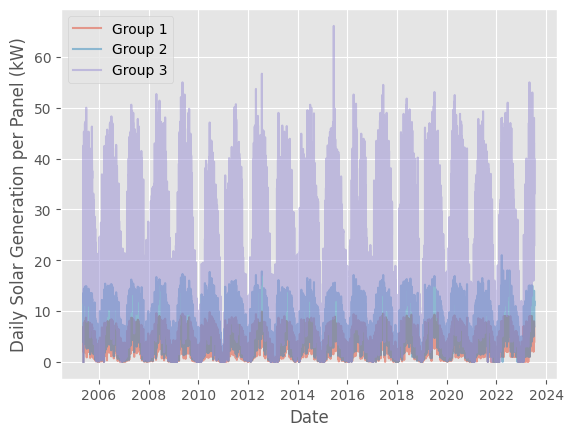

In [13]:
# Check again

sns.lineplot(x=df.index, y=df["group1_pv"], label="Group 1", alpha=0.5) # 8
sns.lineplot(x=df.index, y=df["group2_pv"], label="Group 2", alpha=0.5) #14
sns.lineplot(x=df.index, y=df["group3_pv"], label="Group 3", alpha=0.5) # 44

plt.xlabel('Date')
plt.ylabel('Daily Solar Generation per Panel (kW)')

plt.legend()
plt.show()

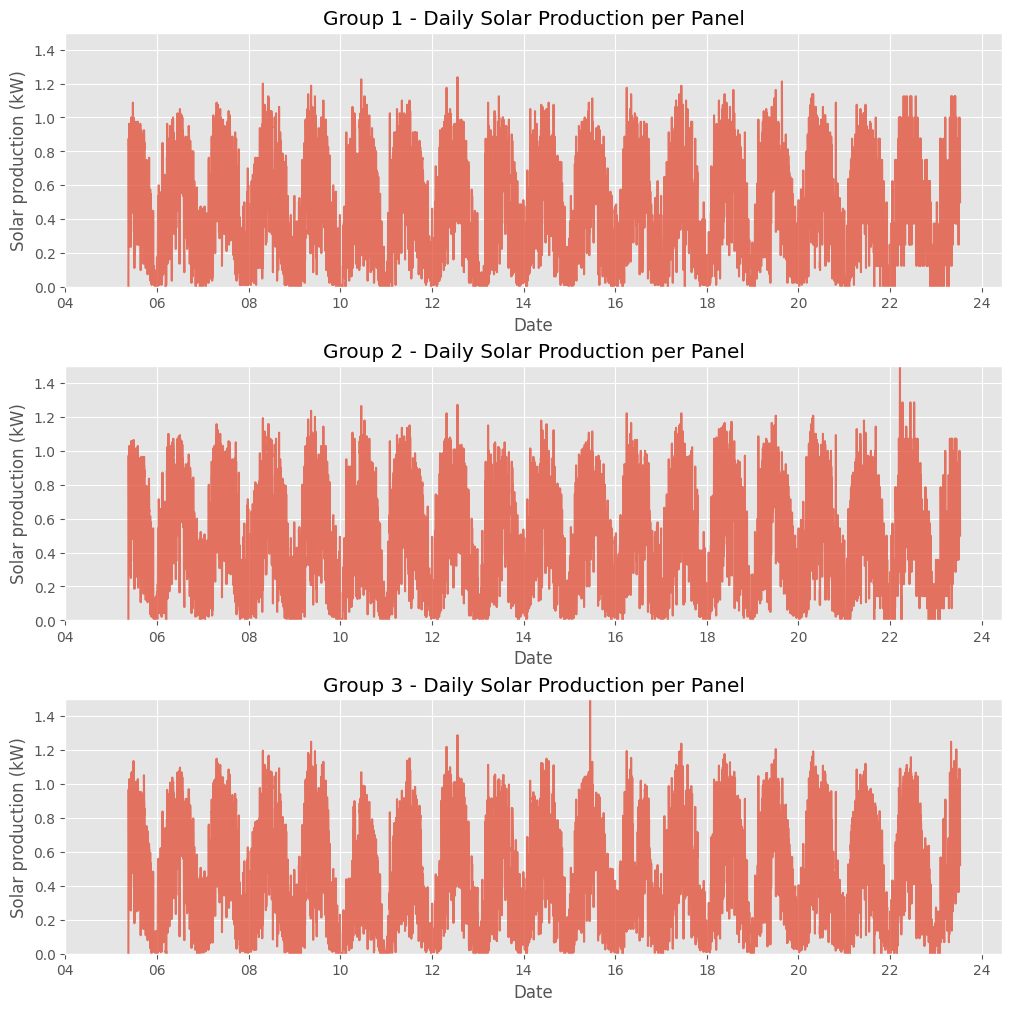

In [14]:
pv_dict = {"Group 1":["group1_pv", 8], "Group 2":["group2_pv", 14], "Group 3":["group3_pv", 44]}
row = len(pv_dict)
_, axes = plt.subplots(row,1, figsize=(10, 10), constrained_layout=True, dpi=100,)


for (key, _ ), ax in zip(pv_dict.items(), axes):
    pv, num_panel = pv_dict[key]
    df_ = df[[pv]].copy()
    # Filter out the data of the common time span
    # df_ = df_.loc[common_idx, :]

    

    # ax.plot(df_.index, df_[['pv', 'load']], label=["PV", "Load"], alpha=0.75)
    ax.plot(df_.index, df_[[pv]]/num_panel, label=["PV"], alpha=0.75)

    ax.set(
        ylim = (0, 1.5),
        title = f"{key} - Daily Solar Production per Panel",
    )

    # Get the existing labels
    labels = [item.get_text() for item in ax.get_xticklabels()]

    # Modify the labels
    new_labels = [label.replace('20', '', 1) for label in labels]

    # Set the new labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(new_labels)

    #print(ax.get_xticklabels())

    ax.set_xlabel("Date")
    ax.set_ylabel("Solar production (kW)")

    #plt.legend()

plt.show()

## EDA - repair of panels

In [15]:
df.head()

,group1_pv,group2_pv,group3_pv
date,,,
2005-05-18,0.0,0.0,0.0
2005-05-19,6.2,11.4,32.2
2005-05-20,7.0,13.6,42.6
2005-05-21,6.2,11.4,36.2
2005-05-22,4.4,8.0,25.0


In [16]:
show_info(df)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,group1_pv,float64,6630,0.0,520,...
1,group2_pv,float64,6630,0.0,872,...
2,group3_pv,float64,6630,0.0,1743,...


In [17]:
# Add a new feature "panel_age"
df["panel_age"] = (df.index - df.index[0]).days / 365.25
df["panel_age"] = df["panel_age"].apply(np.floor).astype("int")

df.head()

,group1_pv,group2_pv,group3_pv,panel_age
date,,,,
2005-05-18,0.0,0.0,0.0,0
2005-05-19,6.2,11.4,32.2,0
2005-05-20,7.0,13.6,42.6,0
2005-05-21,6.2,11.4,36.2,0
2005-05-22,4.4,8.0,25.0,0


In [18]:
df_plus = df.resample("1M").sum().drop(columns=["panel_age"])

# Add more date features
df_plus = add_date_features(df_plus)

df_plus["group1_pv"] = df_plus["group1_pv"]/8
df_plus["group2_pv"] = df_plus["group2_pv"]/14
df_plus["group3_pv"] = df_plus["group3_pv"]/44

show_info(df_plus)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,group1_pv,float64,219,0.0,216,...
1,group2_pv,float64,219,0.0,216,...
2,group3_pv,float64,219,0.0,217,...
3,year,int32,219,0.0,19,...
4,month,int32,219,0.0,12,...
5,week,UInt32,219,0.0,24,...
6,weekday,int32,219,0.0,7,"{1: 32, 2: 32, 0: 32, 3: 31, 4: 31, 5: 31, 6: 30}"
7,day_of_year,int32,219,0.0,23,...


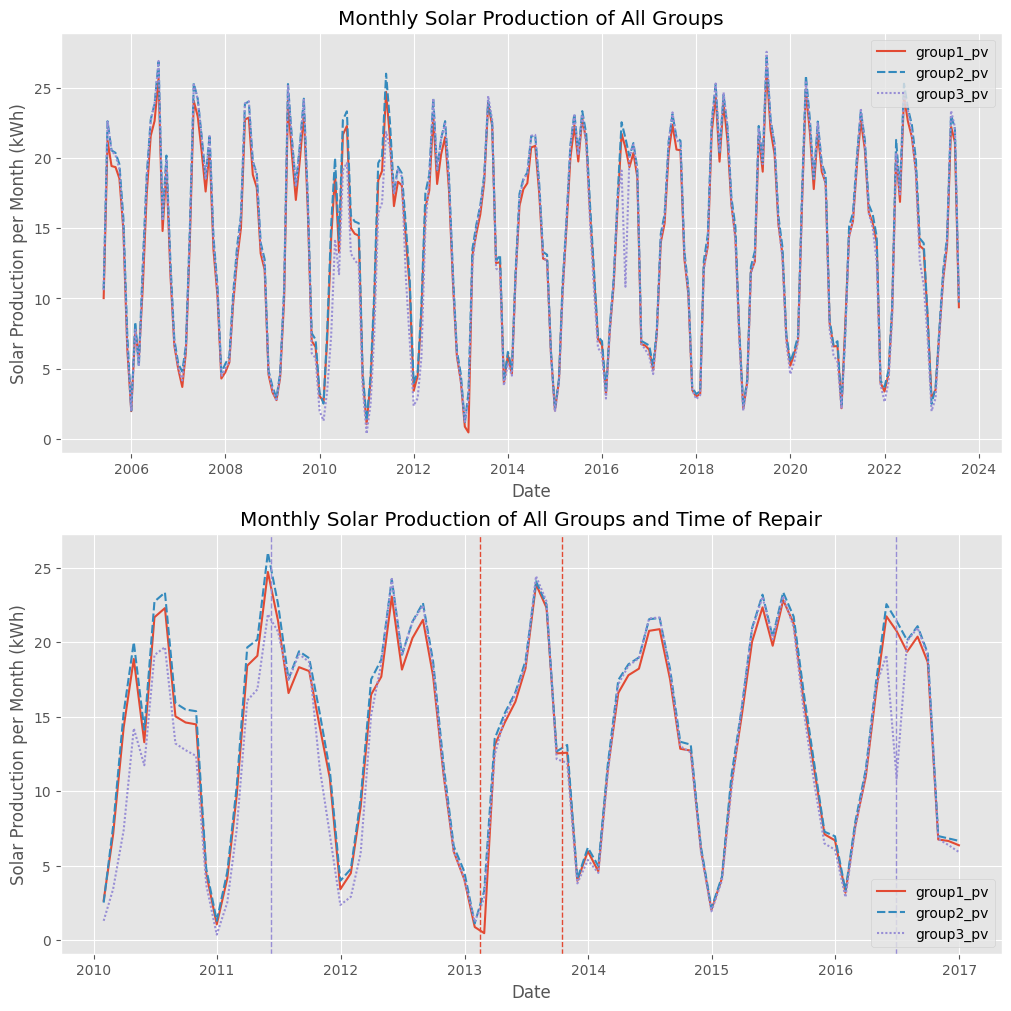

In [19]:
# plt.style.use('default')
# plt.style.use('ggplot')

idx_maintenance_g1 = [
    "17.02.2013", # S repair - group 1
    "17.10.2013", # S repair - group 1
    ]
idx_maintenance_g3 = [
    "09.06.2011", # H repair - group 3
    "27.06.2016", # H repair - group 3
    ]

_, (ax1,ax2) = plt.subplots(2, 1, figsize=(10, 10), constrained_layout=True, dpi=100,)
sns.lineplot(ax=ax1, data=df_plus[["group1_pv", "group2_pv", "group3_pv"]])

ax1.set(
    xlabel= "Date",
    ylabel= "Solar Production per Month (kWh)",
    title="Monthly Solar Production of All Groups",
)

sns.lineplot(ax=ax2, data=df_plus[["group1_pv", "group2_pv", "group3_pv"]].query('index < "2017.01.01" & index > "2009.12.31"'))


for date in idx_maintenance_g1:
    date_line = pd.to_datetime(date, format="%d.%m.%Y")
    ax2.axvline(date_line, color="C0", linestyle='--', lw=1)
for date in idx_maintenance_g3:
    date_line = pd.to_datetime(date, format="%d.%m.%Y")
    ax2.axvline(date_line, color="C2",linestyle='--', lw=1)

ax2.set(
    xlabel= "Date",
    ylabel= "Solar Production per Month (kWh)",
    title="Monthly Solar Production of All Groups and Time of Repair",
)

plt.show()

In [20]:
# filter = (df_plus["group1_pv"] + df_plus["group2_pv"]) / df_plus["group3_pv"] > 2.3
# filter = filter & (df_plus.index > "01.01.2011")
# df_plus[filter]

## EDA - Plots

In [21]:
date_feature_list = ["year", "month", "week", "weekday", "day", "hour", "day_of_year"]

feature_dict = {
    'year': ["bar", "Year", "PV Generation (kWh)", "Total PV Generation for each Year"],
    'month': ["bar", "Month", "PV Generation (kWh)", "Average Total PV Generation over the Month"],
    'week': ["line", "Calendar Week", "PV Generation (kWh)", "Average Total PV Generation for each Calendar Week"],
    'weekday': ["bar", "Calendar Week Day", "PV Generation (kWh)", "Average Total PV Generation for each Calendar Week Day"],
    'day_of_year': ["line", "Date", "PV Generation (kWh)", "Average Total PV Generation for each Calendar Day"],
}

def eda_count_plot(df, fea_dict, fea_item, hh):

    # plt.style.use('default')
    # plt.style.use('fivethirtyeight')
    
    # Set default font size
    plt.rcParams.update({'font.size': 10})

    days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    feature =  fea_item

    plot_kind, xlabel, ylabel, title = fea_dict[feature]

    # Care only "pv"
    target_variable = list(df.columns[df.columns.str.contains("_pv")])[0]
    #target_variable_columns = 
    # print(target_variable)
    df_ = df.groupby([feature])[target_variable]

    if feature in ["day_of_year"]:
        df[target_variable].plot(kind=plot_kind, legend=False, linewidth=0.5)
    elif feature in ['month', 'week', 'day']:
        df_.mean().plot(kind=plot_kind, legend=False)
    elif feature in ['weekday']:
        df_.mean().plot(kind=plot_kind, legend=False)
        plt.gca().set_xticklabels(days)
        plt.xticks(rotation=45)
    else:
        # For "year"
        df_.sum().plot(kind=plot_kind, legend=False)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"{title}\n({hh})", fontdict={'size': 11})

    plt.show()

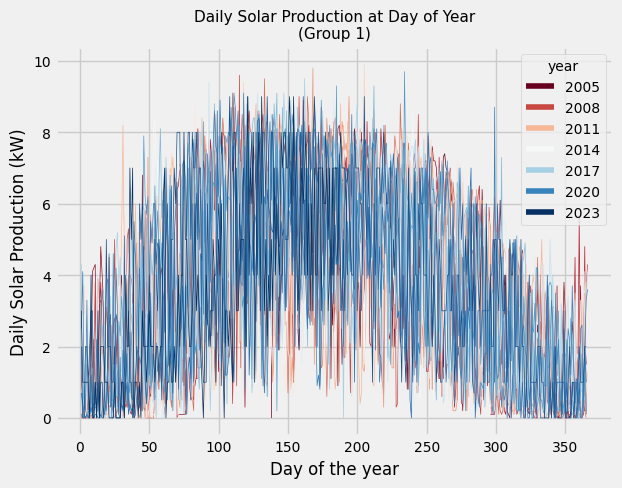

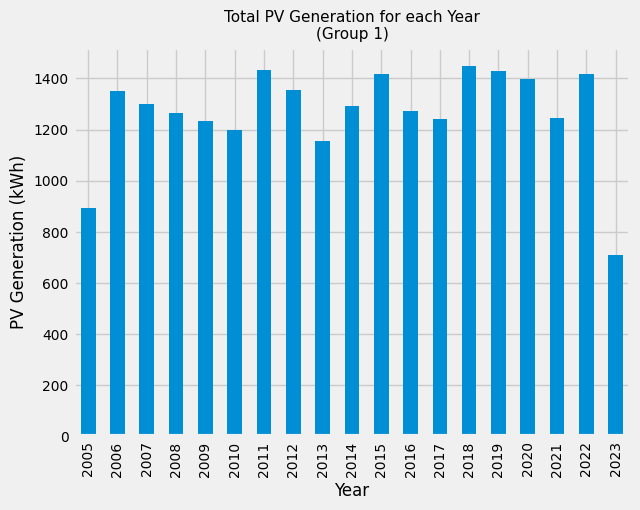

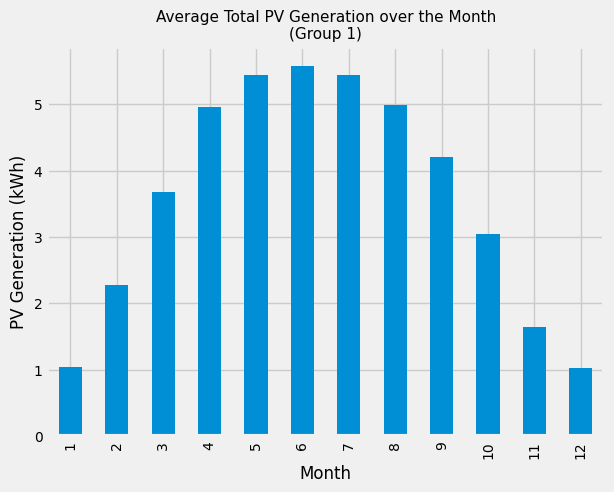

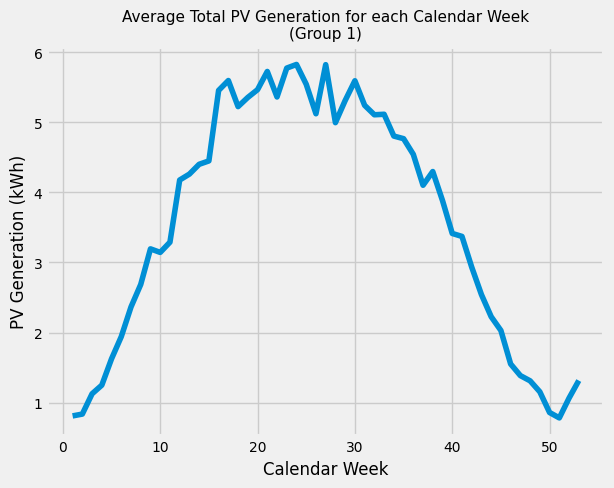

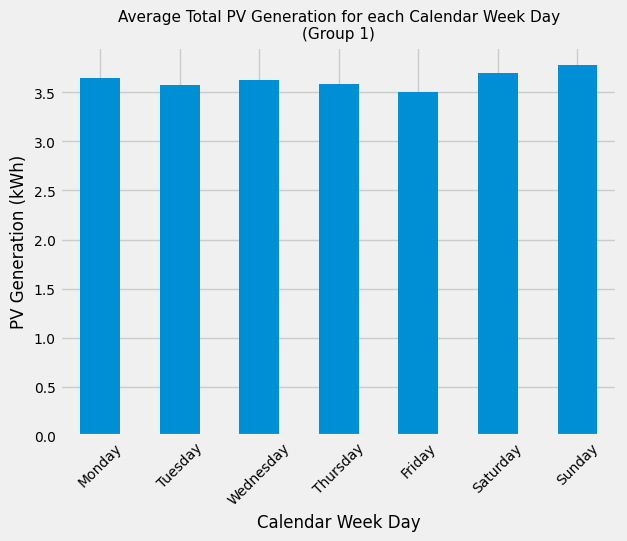

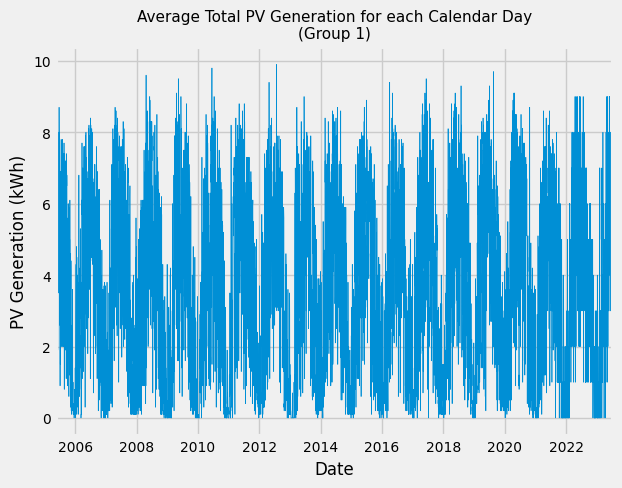

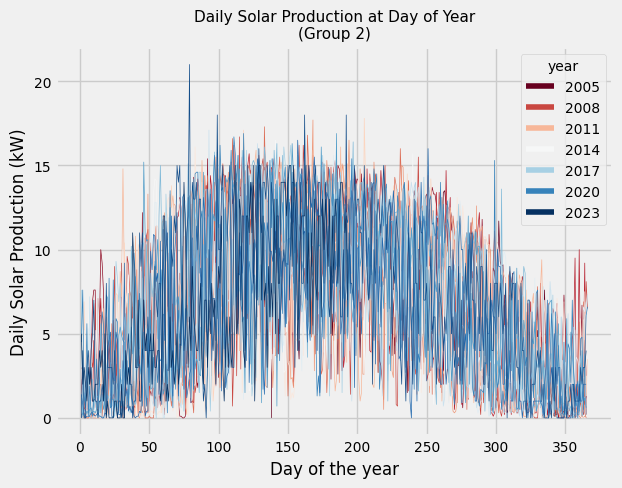

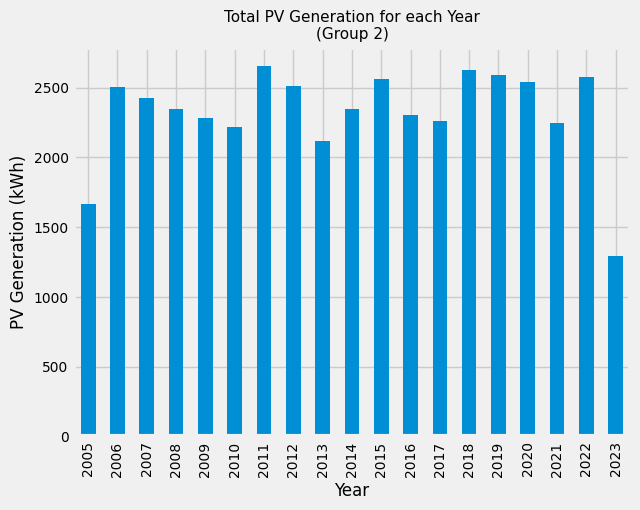

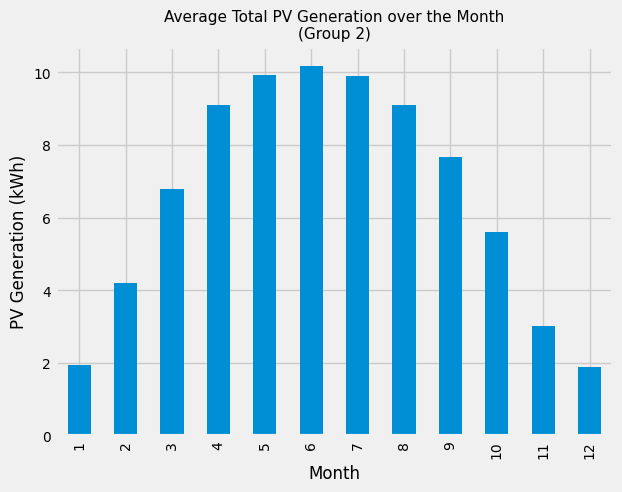

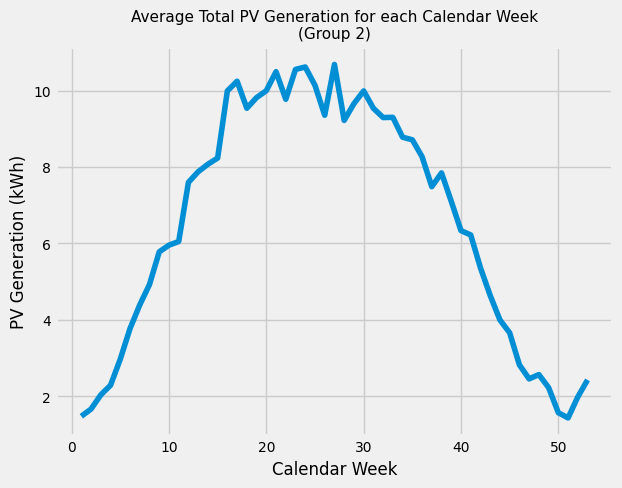

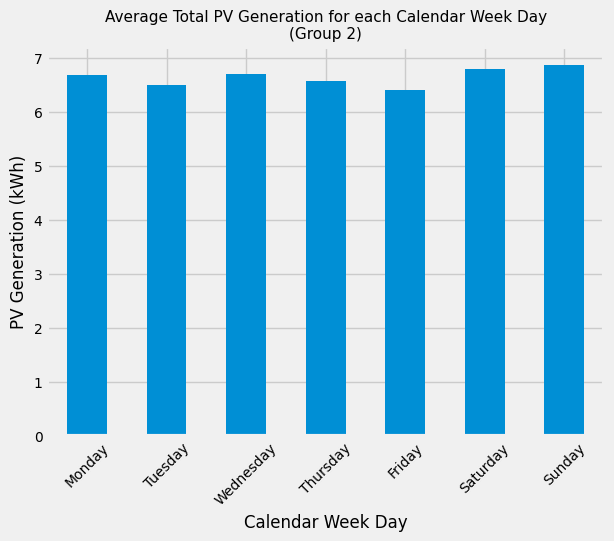

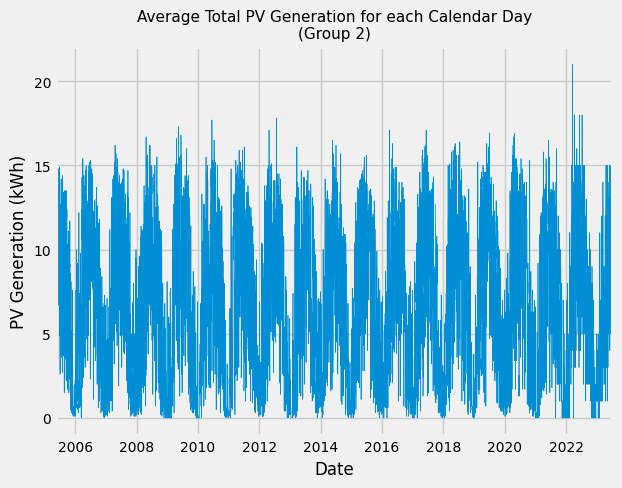

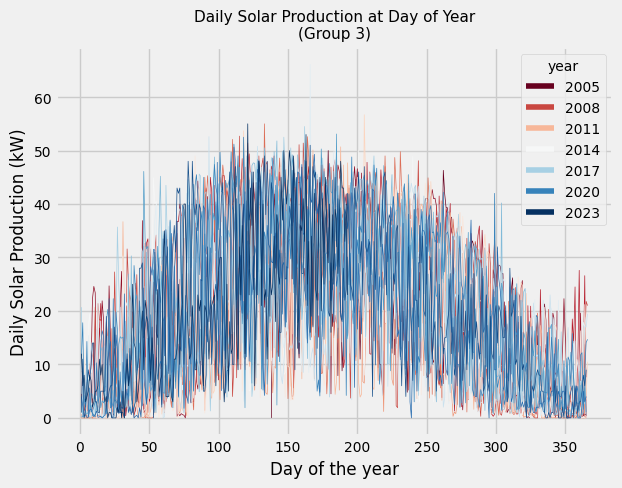

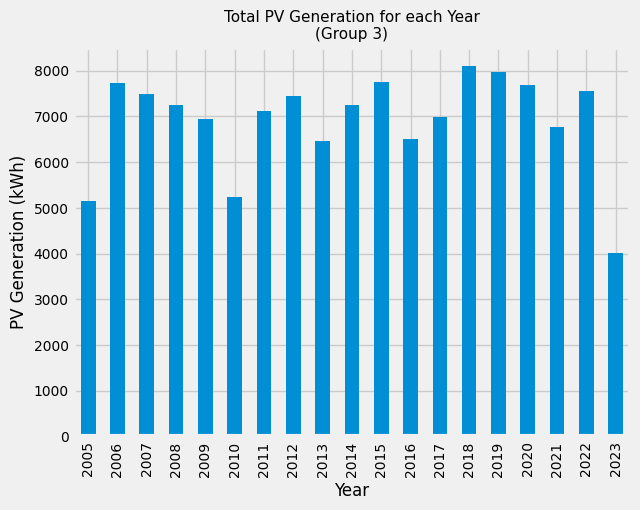

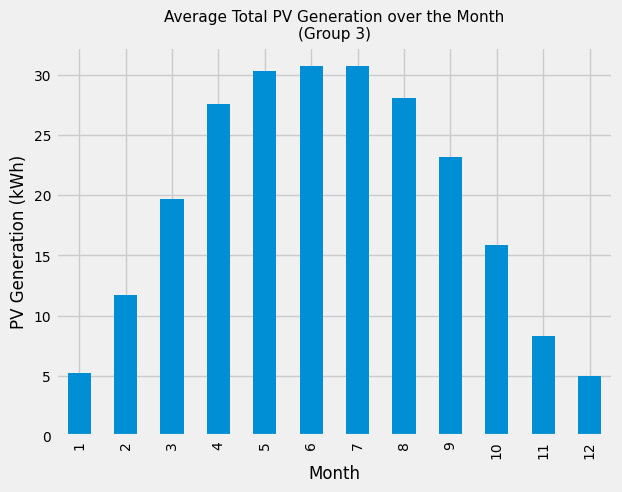

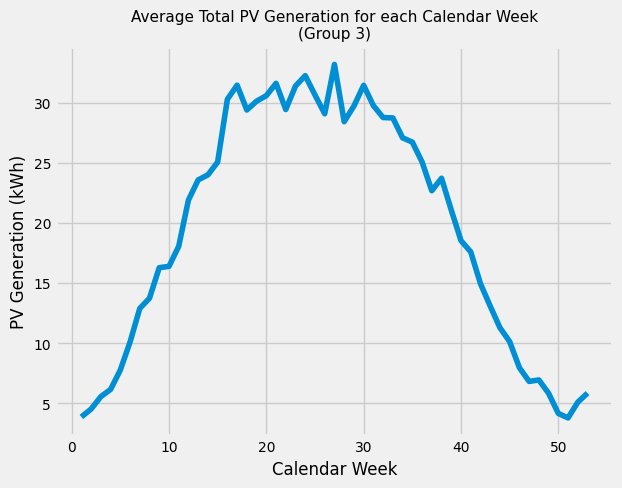

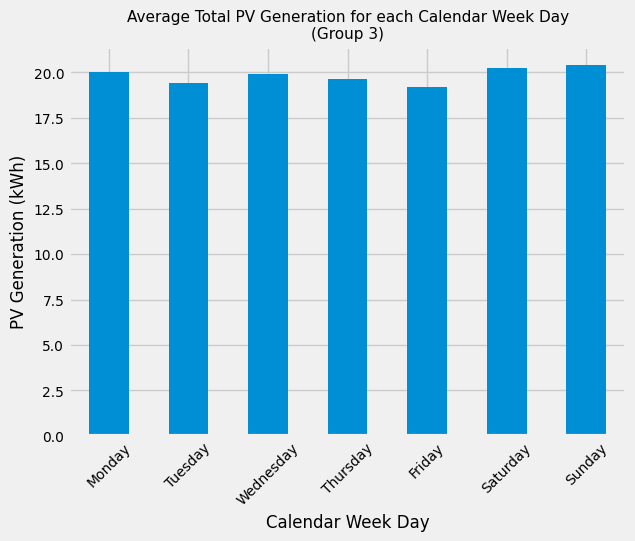

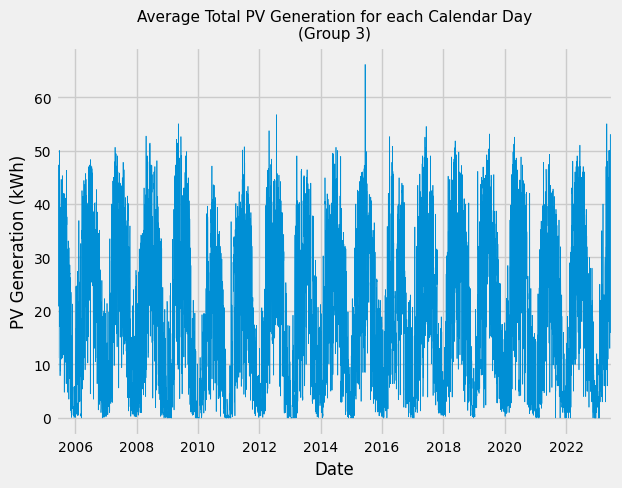

In [22]:
plt.style.use('default')
plt.style.use('fivethirtyeight')
plt.rcParams.update({'font.size': 10})

for key, _ in pv_dict.items():
    #print(f"The EDA feature plots for {hh!r}")

    pv, num_panel = pv_dict[key]
    
    df_ = df[[pv]].copy()

    # Add new features to dataframe of daily resolution
    df_ = add_date_features(df_)

    # display(df_.head())

    # plt.rcParams.update({'font.size': 10})
    sns.lineplot(data=df_, x=df_["day_of_year"], y=df_[pv], hue="year", palette="RdBu", linewidth=0.5).set(
        ylabel="Daily Solar Production (kW)", xlabel="Day of the year",
    )
    plt.gca().set_title(f"Daily Solar Production at Day of Year\n({key})", fontsize=11)
    plt.show()

    # Test whether a column exists or not
    feature_list = [col for col in date_feature_list if col in df_.columns]
    # Delete "year" from the list for better statistics
    # feature_list.remove('year')
    
    for feature in feature_list:
        eda_count_plot(df_, feature_dict, feature, key)

In [23]:
show_info(df)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,group1_pv,float64,6630,0.0,520,...
1,group2_pv,float64,6630,0.0,872,...
2,group3_pv,float64,6630,0.0,1743,...
3,panel_age,int64,6630,0.0,19,...


In [24]:
# import matplotlib as mpl
# print(sns.__version__)
# print(pd.__version__)
# print(mpl.__version__)

## Modeling

### Recap before the modeling

In [25]:
show_info(df_plus)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,group1_pv,float64,219,0.0,216,...
1,group2_pv,float64,219,0.0,216,...
2,group3_pv,float64,219,0.0,217,...
3,year,int32,219,0.0,19,...
4,month,int32,219,0.0,12,...
5,week,UInt32,219,0.0,24,...
6,weekday,int32,219,0.0,7,"{1: 32, 2: 32, 0: 32, 3: 31, 4: 31, 5: 31, 6: 30}"
7,day_of_year,int32,219,0.0,23,...


In [26]:
# Add the decomposed data features
df_final = add_date_features(df)

# Take the average over number of panels
df_final["group1_pv"] = df_final["group1_pv"]/8
df_final["group2_pv"] = df_final["group2_pv"]/14
df_final["group3_pv"] = df_final["group3_pv"]/44

show_info(df_final)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,group1_pv,float64,6630,0.0,520,...
1,group2_pv,float64,6630,0.0,872,...
2,group3_pv,float64,6630,0.0,1743,...
3,panel_age,int64,6630,0.0,19,...
4,year,int32,6630,0.0,19,...
5,month,int32,6630,0.0,12,...
6,week,UInt32,6630,0.0,53,...
7,weekday,int32,6630,0.0,7,"{2: 948, 3: 947, 4: 947, 5: 947, 6: 947, 0: 94..."
8,day_of_year,int32,6630,0.0,366,...


#### Correlation Plots

In [27]:
def plot_corr(df):
    #plt.figure(figsize=(8, 7))
    corr_matrix = df.corr()

    # Heat map
    filter = (corr_matrix >= 0.2) | (corr_matrix <= -0.2)

    ax = sns.heatmap(corr_matrix[filter], linewidths = .5, annot = True, square=True, fmt=".2f", annot_kws={"fontsize":8}, cmap='coolwarm',cbar=False)
    ax.tick_params(axis='x', rotation=45)

    plt.show()

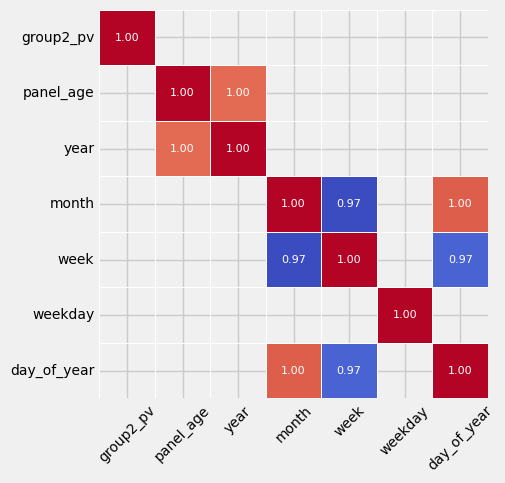

In [28]:
# Take Group 2 as it is the only has no repairs
plot_corr(df_final.drop(columns=["group1_pv", "group3_pv"]))

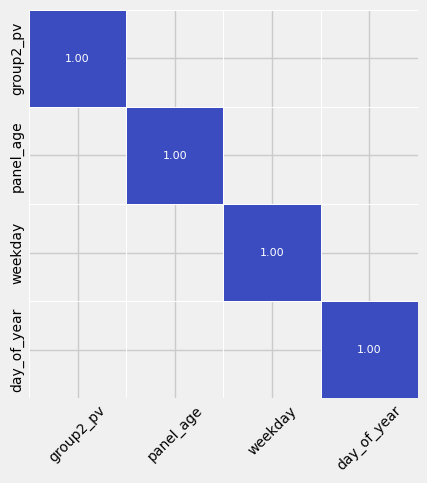

In [29]:
plot_corr(df_final.drop(columns=["group1_pv", "group3_pv", "year", "month", "week"]))

### RF (1st model): no weather

- no weather information
- only 'panel_age', 'day_of_year'
- 'panel_age' one hot encoded

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

RSEED = 42

In [31]:
# Define features and target
X = df_final[['panel_age', 'day_of_year']]
X = pd.get_dummies(X, columns=['panel_age'], drop_first=True)
y = df_final['group2_pv']

# Split data into train and test sets. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model = RandomForestRegressor(n_estimators=500, random_state=42)

# Fit the model
model.fit(X_train, y_train)

# Predict on the test data
y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.0535556006020283


In [32]:
y.head()

date
2005-05-18    0.000000
2005-05-19    0.814286
2005-05-20    0.971429
2005-05-21    0.814286
2005-05-22    0.571429
Name: group2_pv, dtype: float64

In [33]:
# Evaluate the model

r2 = r2_score(y_test, y_pred)

print(f'R^2 Score: {r2}')

R^2 Score: 0.5064953970417101


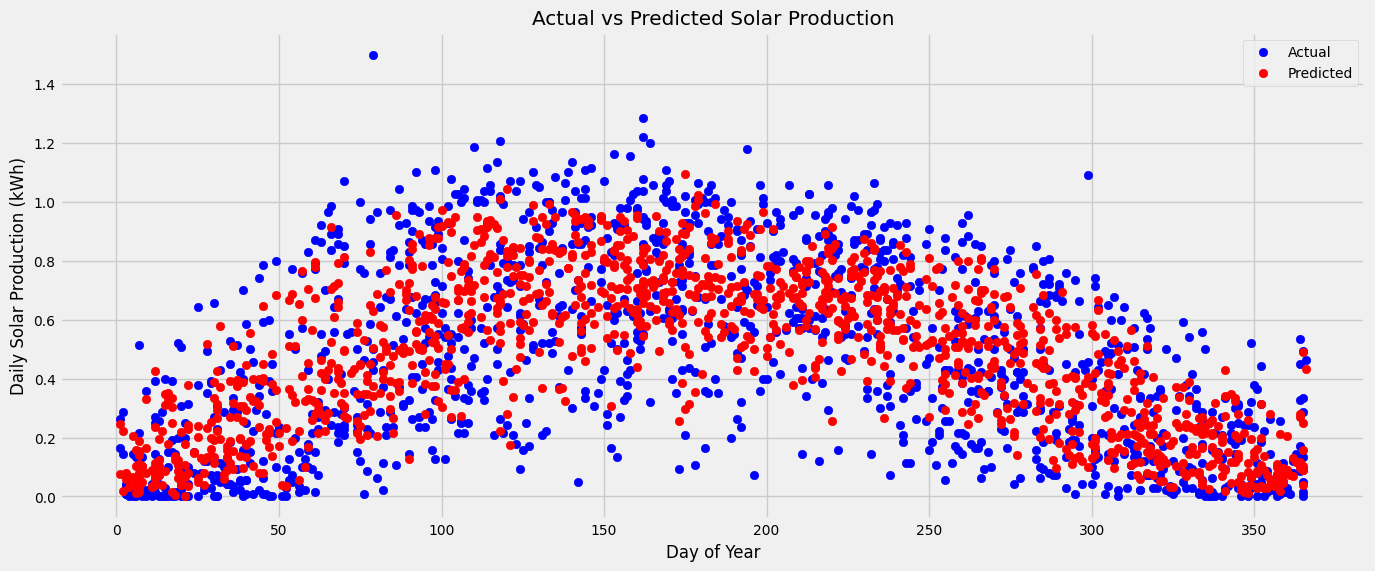

In [34]:
plt.figure(figsize=(15, 6))
plt.scatter(X_test['day_of_year'], y_test, color='blue', label='Actual')
plt.scatter(X_test['day_of_year'], y_pred, color='red', label='Predicted')
plt.xlabel('Day of Year')
plt.ylabel('Daily Solar Production (kWh)')
plt.title('Actual vs Predicted Solar Production')
plt.legend()
plt.show()

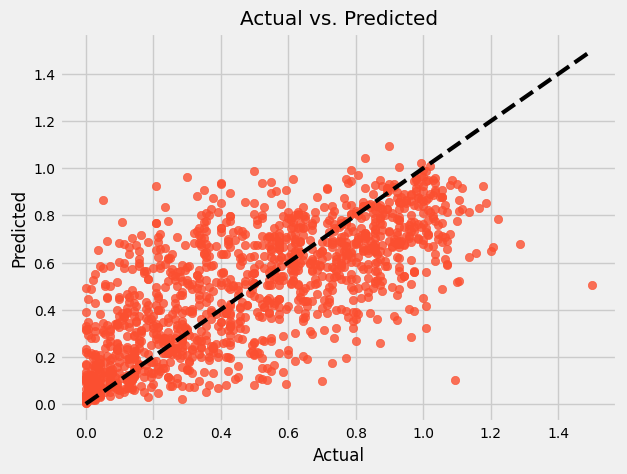

In [35]:
plt.scatter(y_test, y_pred, color='C1', alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

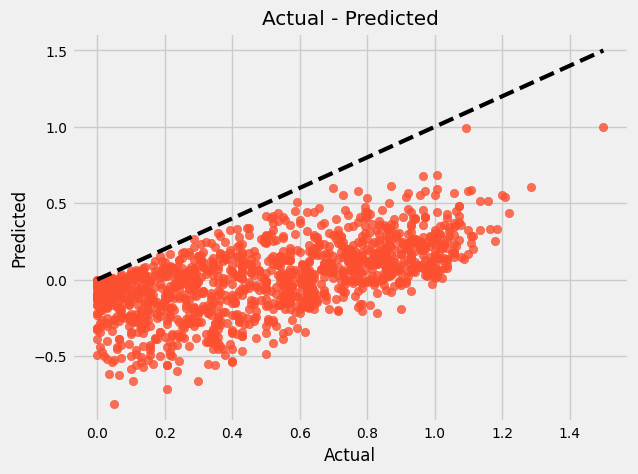

In [36]:
plt.scatter(y_test, y_test-y_pred, color='C1', alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)
#plt.xlim(-10,20)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual - Predicted')
plt.show()

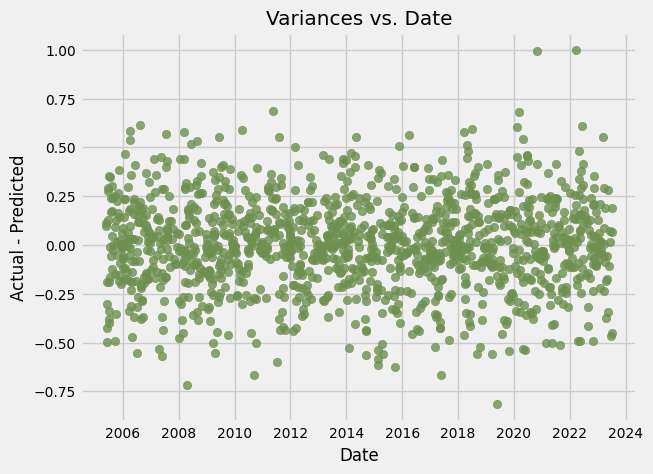

In [37]:
plt.scatter(y_test.index, y_test-y_pred, color='C3', alpha=0.8)
#plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)
#plt.xlim(-10,20)
plt.xlabel('Date')
plt.ylabel('Actual - Predicted')
plt.title('Variances vs. Date')
plt.show()

### RF: all weather features

- all weather information as features
- 'panel_age' included and encoded

In [38]:
# Read csv file 
df_weather = pd.read_csv("../data/cleaned/weather_goerlitz.csv", parse_dates=["MESS_DATUM"])

# Drop useless information
df_weather.drop(columns=["Unnamed: 0", "index", "STATIONS_ID", "eor"], inplace=True)

rename_dict = {
    "MESS_DATUM": "date",
    "QN_3": "quality_level_3",
    "FX": "max_windgust",
    "FM": "mean_wind_velocity",
    "QN_4": "quality_level_4",
    "RSK": "precipitation_height",
    "RSKF": "precipitation_form",
    "SDK": "sunshine_duration",
    "SHK_TAG": "snow_depth",
    "NM": "mean_cloud_cover",
    "VPM": "mean_vapor_pressure",
    "PM": "mean_pressure",
    "TMK": "mean_temperature",
    "UPM": "mean_relative_humidity",
    "TXK": "max_temperature",
    "TNK": "min_temperature",
    "TGK": "min_air_temperature"
}

# Rename columns
df_weather.rename(columns=rename_dict, inplace=True)

# Set the index
df_weather.set_index(["date"], inplace=True)

# Filter out only the weather data within the same range as the household data
df_weather = df_weather.query('index > "2005-05-17" & index < "2023-07-13"')
show_info(df_weather)
df_weather.head()

,quality_level_3,max_windgust,mean_wind_velocity,quality_level_4,precipitation_height,precipitation_form,sunshine_duration,snow_depth,mean_cloud_cover,mean_vapor_pressure,mean_pressure,mean_temperature,mean_relative_humidity,max_temperature,min_temperature,min_air_temperature,color_tmk
date,,,,,,,,,,,,,,,,,
2005-05-18,10.0,8.2,3.2,10.0,0.0,6.0,0.0,0.0,7.3,10.1,989.8,7.9,94.0,9.6,4.4,1.6,0
2005-05-19,10.0,8.9,1.5,10.0,0.0,0.0,12.0,0.0,2.5,7.5,996.7,9.4,67.0,15.0,2.6,-0.1,0
2005-05-20,10.0,7.2,2.0,10.0,0.0,0.0,13.5,0.0,3.7,8.5,994.1,11.9,64.0,18.1,3.6,1.1,0
2005-05-21,10.0,11.1,3.5,10.0,0.0,6.0,9.5,0.0,6.0,11.0,987.5,16.7,59.0,23.6,6.5,4.1,0
2005-05-22,10.0,9.3,2.1,10.0,0.0,6.0,4.4,0.0,6.3,14.1,985.2,17.6,71.0,22.0,13.0,10.5,0


In [39]:
display(df_final.shape)
display(df_weather.shape)

(6630, 9)

(6980, 17)

In [40]:
display(df_final.index.min(),df_final.index.max())
display(df_weather.index.min(),df_weather.index.max())
display(df_weather.index.nunique())

Timestamp('2005-05-18 00:00:00')

Timestamp('2023-07-12 00:00:00')

Timestamp('2005-05-18 00:00:00')

Timestamp('2023-07-12 00:00:00')

6630

In [41]:
df_weather[df_weather.index.duplicated()]

# 350 rows × 17 columns

,quality_level_3,max_windgust,mean_wind_velocity,quality_level_4,precipitation_height,precipitation_form,sunshine_duration,snow_depth,mean_cloud_cover,mean_vapor_pressure,mean_pressure,mean_temperature,mean_relative_humidity,max_temperature,min_temperature,min_air_temperature,color_tmk
date,,,,,,,,,,,,,,,,,
2022-01-16,10.0,14.1,6.2,3.0,0.3,8.0,5.450,0.0,7.5,5.6,992.31,1.0,84.17,3.5,-2.2,-3.6,0
2022-01-17,10.0,21.1,7.0,3.0,3.2,8.0,0.000,0.0,5.2,6.2,992.56,2.3,85.92,4.6,-0.5,-1.7,0
2022-01-18,10.0,8.6,3.3,3.0,0.0,6.0,0.050,0.0,6.5,5.8,1005.20,1.0,87.92,2.4,-0.6,-1.5,0
2022-01-19,10.0,14.8,6.0,3.0,0.6,8.0,7.250,0.0,6.3,5.8,994.68,1.5,84.50,2.7,-0.3,-1.0,0
2022-01-20,10.0,19.9,6.7,3.0,1.0,8.0,1.933,0.0,7.0,5.0,986.03,0.3,79.38,2.8,-2.3,-2.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-27,3.0,13.5,5.5,3.0,0.0,6.0,0.350,0.0,6.4,6.1,994.29,3.3,78.50,5.2,0.1,-1.9,0
2022-12-28,3.0,16.8,8.5,3.0,0.3,6.0,1.050,0.0,7.6,6.5,988.86,4.2,78.88,6.8,1.2,-0.6,0
2022-12-29,3.0,17.4,8.8,3.0,0.2,6.0,2.250,0.0,7.4,7.6,981.20,7.9,71.75,9.9,5.8,4.4,0


In [42]:
# Create a boolean mask for duplicated indices
mask = df_weather.index.duplicated(keep='first')

# Use the mask to drop the duplicated rows
df_weather = df_weather[~mask]

df_weather.shape

(6630, 17)

In [43]:
df_final_weather = df_final.copy()
df_final_weather = df_final_weather.join(df_weather)

df_final_weather["precipitation_form"] = df_final_weather["precipitation_form"].astype("int")

In [44]:
show_info(df_final_weather)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,group1_pv,float64,6630,0.00,520,...
1,group2_pv,float64,6630,0.00,872,...
2,group3_pv,float64,6630,0.00,1743,...
3,panel_age,int64,6630,0.00,19,...
4,year,int32,6630,0.00,19,...
5,month,int32,6630,0.00,12,...
6,week,UInt32,6630,0.00,53,...
7,weekday,int32,6630,0.00,7,"{2: 948, 3: 947, 4: 947, 5: 947, 6: 947, 0: 94..."
8,day_of_year,int32,6630,0.00,366,...
9,quality_level_3,float64,6630,0.00,3,"{10.0: 6315, 3.0: 249, 1.0: 66}"


In [45]:
df_final_weather.fillna(method="backfill", inplace=True)

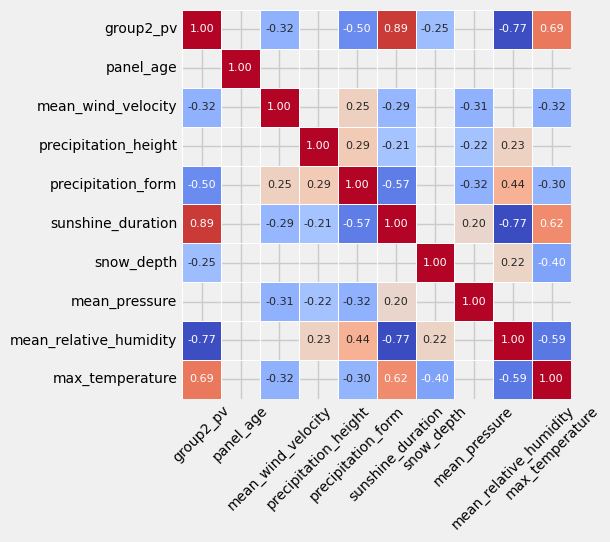

In [46]:
plot_corr(df_final_weather.drop(columns=["group1_pv", "group3_pv", "year", "month", "week", "weekday", 
                                         "color_tmk" , "day_of_year", "quality_level_3", "quality_level_4", 
                                         "mean_temperature", "min_temperature", "min_air_temperature", "mean_cloud_cover", "max_windgust", "mean_vapor_pressure"]))

In [78]:
# Define features and target
X2 = df_final_weather.drop(columns=["group1_pv", "group2_pv", "group3_pv", "year", "month", "week", "weekday", "color_tmk" , "day_of_year"])
X2 = pd.get_dummies(X2, columns=['panel_age'], drop_first=True)
y2 = df_final_weather['group2_pv']

# Split data into train and test sets. 
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42,)

# Initialize the model
model2 = RandomForestRegressor(n_estimators=500, random_state=42, max_depth=10, max_features='sqrt',)

# Fit the model
model2.fit(X_train2, y_train2)

# Predict on the test data
y_pred2 = model2.predict(X_test2)

print(f"Mean Squared Error: {mean_squared_error(y_test2, y_pred2):.3f}")
print(f'R^2 Score: {r2_score(y_test2, y_pred2):.3f}')

Mean Squared Error: 0.016
R^2 Score: 0.849


In [48]:
X2.head()

,quality_level_3,max_windgust,mean_wind_velocity,quality_level_4,precipitation_height,precipitation_form,sunshine_duration,snow_depth,mean_cloud_cover,mean_vapor_pressure,...,panel_age_9,panel_age_10,panel_age_11,panel_age_12,panel_age_13,panel_age_14,panel_age_15,panel_age_16,panel_age_17,panel_age_18
date,,,,,,,,,,,,,,,,,,,,,
2005-05-18,10.0,8.2,3.2,10.0,0.0,6,0.0,0.0,7.3,10.1,...,False,False,False,False,False,False,False,False,False,False
2005-05-19,10.0,8.9,1.5,10.0,0.0,0,12.0,0.0,2.5,7.5,...,False,False,False,False,False,False,False,False,False,False
2005-05-20,10.0,7.2,2.0,10.0,0.0,0,13.5,0.0,3.7,8.5,...,False,False,False,False,False,False,False,False,False,False
2005-05-21,10.0,11.1,3.5,10.0,0.0,6,9.5,0.0,6.0,11.0,...,False,False,False,False,False,False,False,False,False,False
2005-05-22,10.0,9.3,2.1,10.0,0.0,6,4.4,0.0,6.3,14.1,...,False,False,False,False,False,False,False,False,False,False


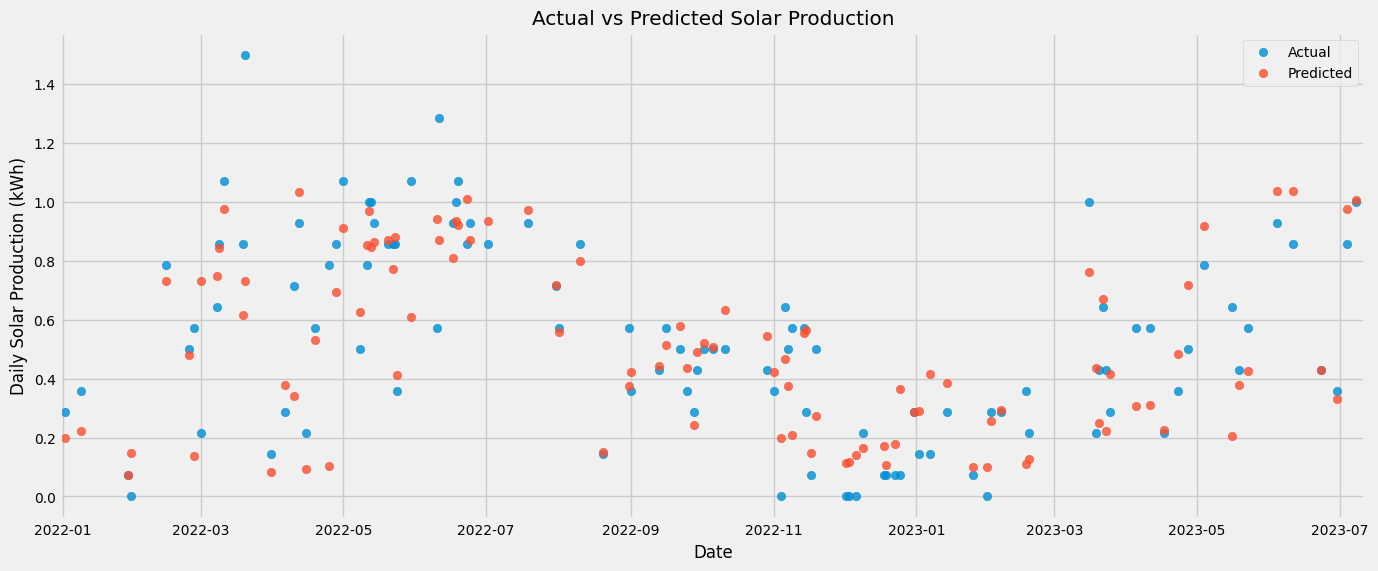

In [49]:
plt.figure(figsize=(15, 6))
plt.scatter(X_test2.index, y_test2, label='Actual', alpha=0.8)
plt.scatter(X_test2.index, y_pred2, label='Predicted', alpha=0.8)

plt.xlim(pd.to_datetime("2021.12.31"),pd.to_datetime("2023.07.12"))
plt.xlabel('Date')
plt.ylabel('Daily Solar Production (kWh)')
plt.title('Actual vs Predicted Solar Production')
plt.legend()
plt.show()

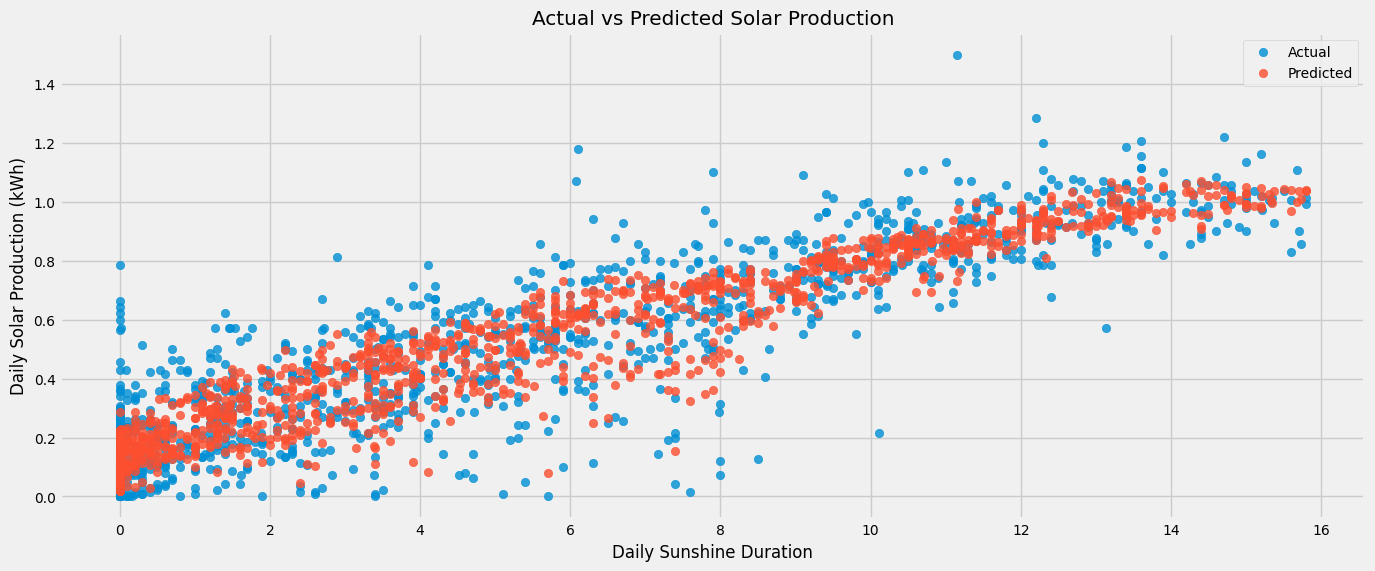

In [50]:
plt.figure(figsize=(15, 6))
plt.scatter(X_test2['sunshine_duration'], y_test2, label='Actual', alpha=0.8)
plt.scatter(X_test2['sunshine_duration'], y_pred2, label='Predicted', alpha=0.8)
plt.xlabel('Daily Sunshine Duration')
plt.ylabel('Daily Solar Production (kWh)')
plt.title('Actual vs Predicted Solar Production')
plt.legend()
plt.show()

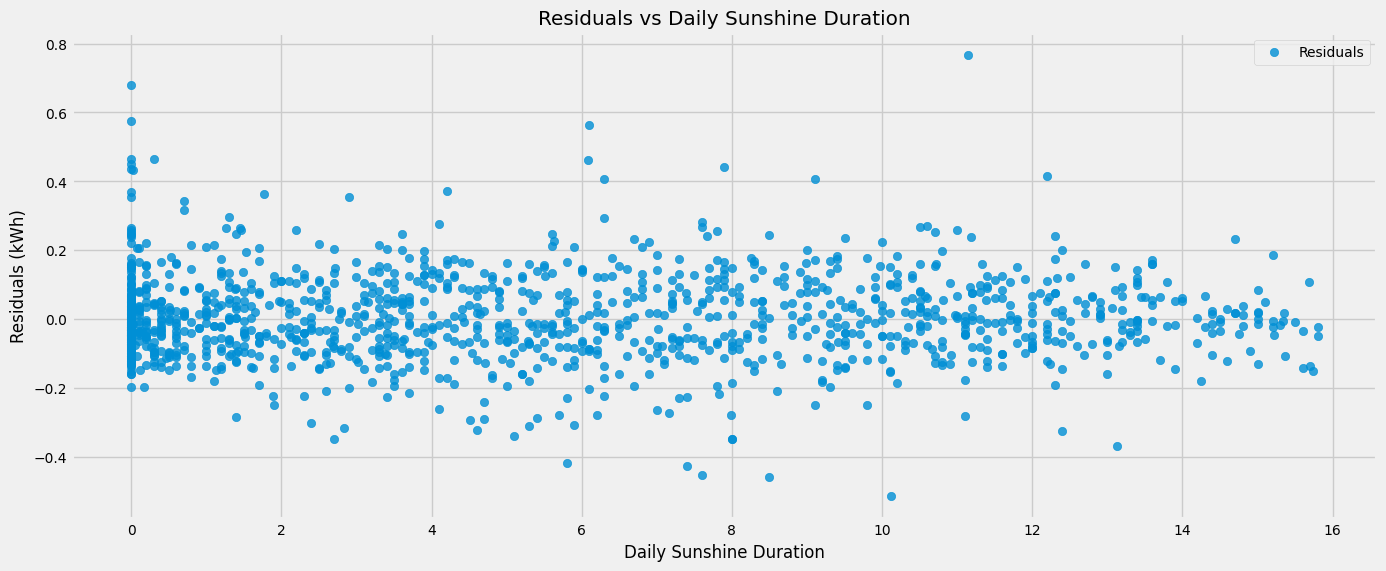

In [51]:
plt.figure(figsize=(15, 6))
plt.scatter(X_test2['sunshine_duration'], y_test2 - y_pred2, label='Residuals', alpha=0.8)
#plt.scatter(X_test2['SDK'], y_pred2, color='red', label='Predicted', alpha=0.8)
plt.xlabel('Daily Sunshine Duration')
plt.ylabel('Residuals (kWh)')
plt.title('Residuals vs Daily Sunshine Duration')
plt.legend()
plt.show()

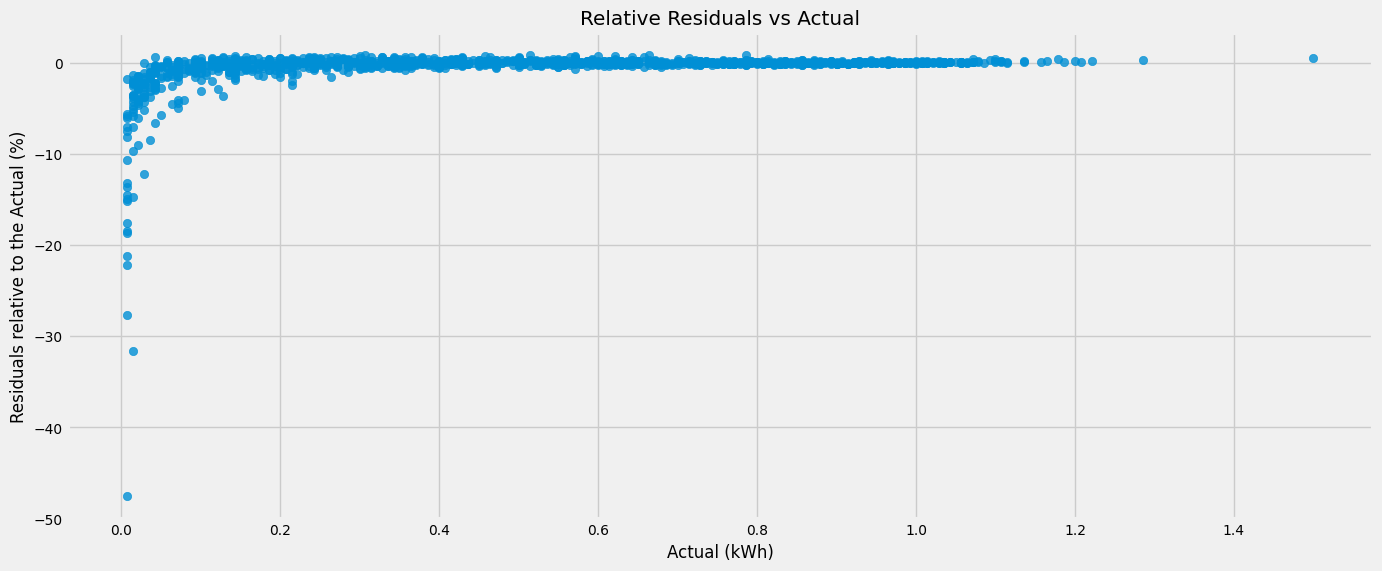

In [52]:
plt.figure(figsize=(15, 6))
plt.scatter(y_test2, (y_test2-y_pred2)/y_test2, alpha=0.8)
plt.xlabel('Actual (kWh)')
plt.ylabel('Residuals relative to the Actual (%)')
plt.title('Relative Residuals vs Actual')
plt.show()

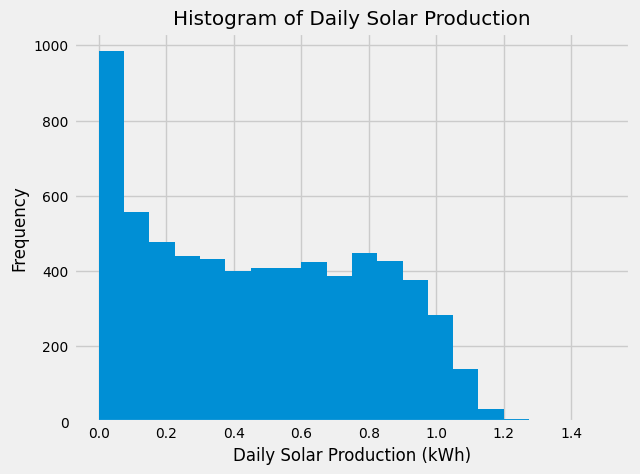

In [53]:
plt.hist(x=df_final_weather['group2_pv'], bins=20)
plt.xlabel("Daily Solar Production (kWh)")
plt.ylabel("Frequency")
plt.title("Histogram of Daily Solar Production")
plt.show()

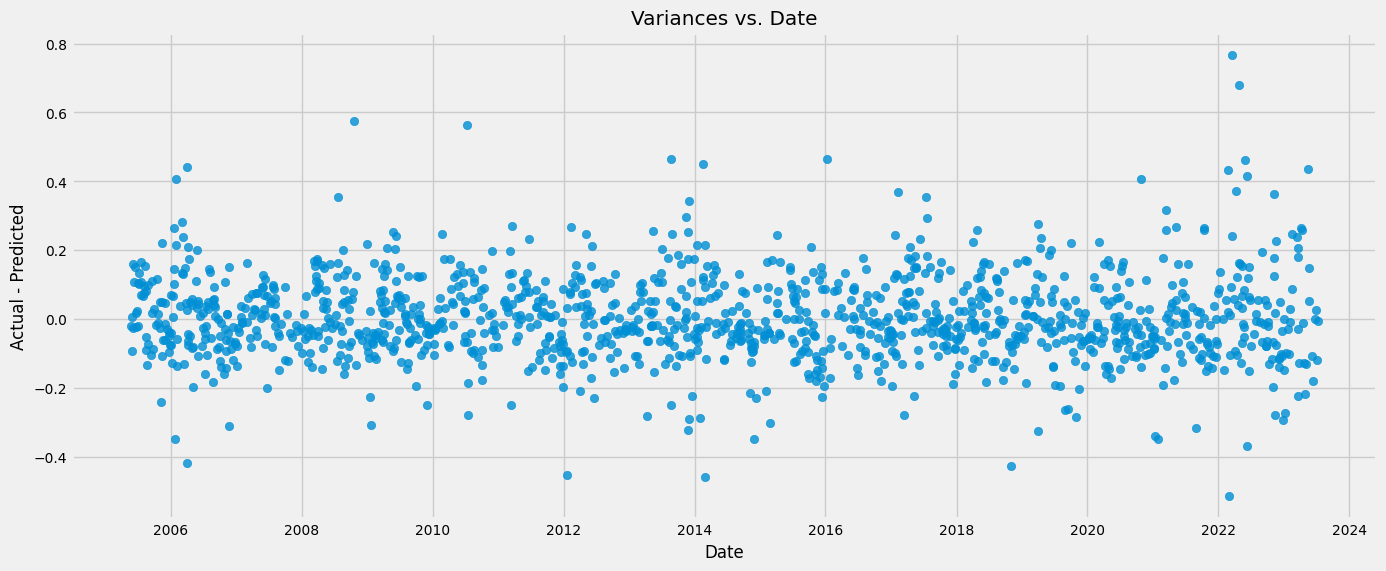

In [54]:
plt.figure(figsize=(15, 6))
plt.scatter(y_test2.index, y_test2-y_pred2, alpha=0.8)
#plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)
#plt.xlim(-10,20)
plt.xlabel('Date')
plt.ylabel('Actual - Predicted')
plt.title('Variances vs. Date')
plt.show()

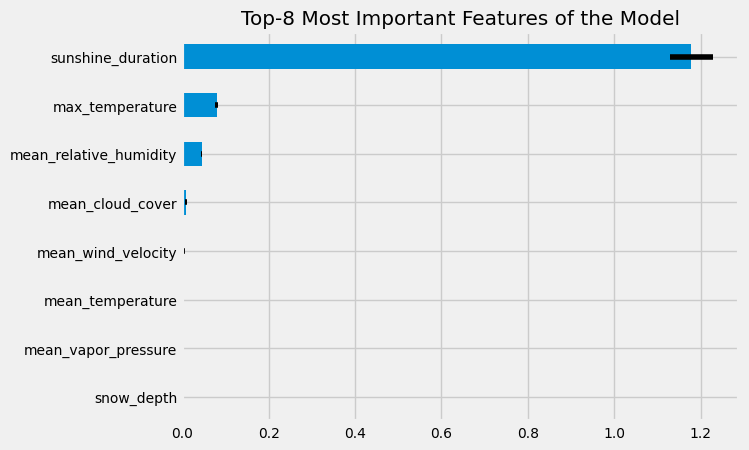

In [55]:
# took ~30 s from a MacBook Pro 2023
# Output the importance of top features
compute_importance(model2, X_test2, y_test2, rseed=42, top=8)

### RF: interested weather features

- only selected weather information

In [79]:
X3 = df_final_weather[['panel_age', "sunshine_duration", "precipitation_form", "precipitation_height", 
                       "mean_wind_velocity", "snow_depth", "mean_temperature", "mean_relative_humidity"]].copy()
X3 = pd.get_dummies(X3, columns=['panel_age', "precipitation_form"], drop_first=True)
y3 = df_final_weather['group2_pv']

# Split data into train and test sets. 
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)

# Initialize the model
model3 = RandomForestRegressor(n_estimators=500, random_state=42, max_features='sqrt', max_depth=10,)

# Fit the model
model3.fit(X_train3, y_train3)

# Predict on the test data
y_pred3 = model3.predict(X_test3)

print(f"Mean Squared Error: {mean_squared_error(y_test3, y_pred3):.3f}")
print(f'R^2 Score: {r2_score(y_test3, y_pred3):.3f}')

# Mean Squared Error: 0.015549141535382236

Mean Squared Error: 0.017
R^2 Score: 0.848


In [80]:
model3.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 10,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 500,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [58]:
X3.describe().T

,count,mean,std,min,25%,50%,75%,max
sunshine_duration,6630.0,5.160313,4.577071,0.00,0.6,4.4,8.9,16.0
precipitation_height,6630.0,1.745385,4.328684,0.00,0.0,0.0,1.5,65.8
mean_wind_velocity,6630.0,3.769155,1.801207,0.20,2.4,3.3,4.7,11.9
snow_depth,6630.0,0.806938,3.257142,0.00,0.0,0.0,0.0,36.0
mean_temperature,6630.0,9.784676,7.851801,-17.80,3.8,9.9,16.0,29.4
mean_relative_humidity,6630.0,76.475098,12.445928,33.75,68.0,78.0,86.0,100.0


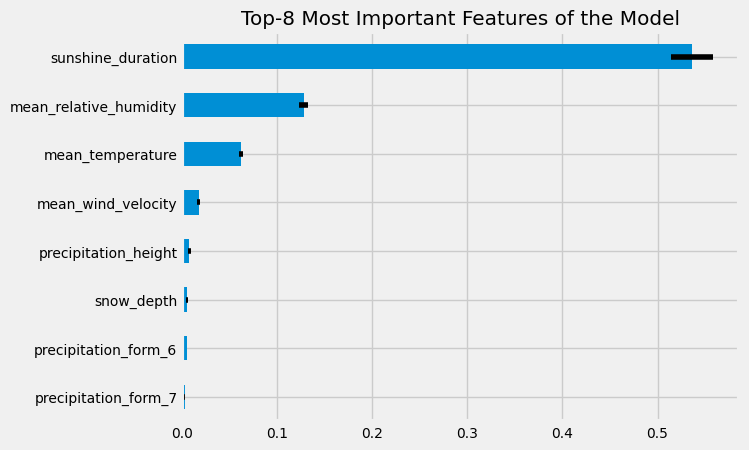

In [81]:
# took ~12 s from a MacBook Pro 2023
# Output the importance of top features
compute_importance(model3, X_test3, y_test3, rseed=42, top=8)

### XGBoost: interested weather features

In [60]:
from xgboost import XGBRegressor # pip install xgboost==1.7.5

In [61]:
# Initialize the model
model4 = XGBRegressor(n_estimators=500, learning_rate=0.01, random_state=42, use_label_encoder=False, eval_metric='rmse')

# Fit the model
model4.fit(X_train3, y_train3)

# Predict on the test data
y_pred4 = model4.predict(X_test3)

print(f"Mean Squared Error: {mean_squared_error(y_test3, y_pred4):.3f}")
print(f'R^2 Score: {r2_score(y_test3, y_pred4):.3f}')

Mean Squared Error: 0.015
R^2 Score: 0.859


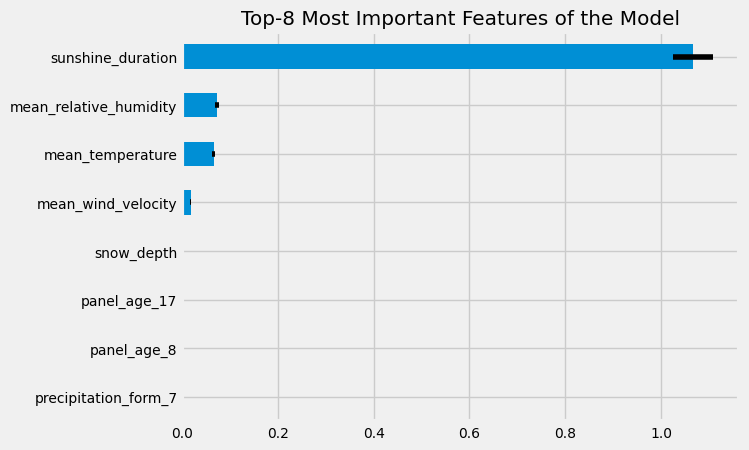

In [62]:
# Output the importance of top features
compute_importance(model4, X_test3, y_test3, rseed=42, top=8)

## Testing the models on other data

- the models are built on Group 2 where no repair took place ever
- 'model3' is the RF model considers only interested weather features
- 'model4' same as 'model3' but a XGBoost model

### On Group 1 - RF

In [82]:
# Predict on the test data
# X3 = df_final_weather[['panel_age', "sunshine_duration", "precipitation_form", "precipitation_height", 
#                        "mean_wind_velocity", "snow_depth", "mean_temperature", "mean_relative_humidity"]].copy()
y_test_g1 = df_final_weather['group1_pv']
y_pred_g1 = model3.predict(X3)

print(f"Mean Squared Error: {mean_squared_error(y_test_g1, y_pred_g1):.3f}")
print(f'R^2 Score: {r2_score(y_test_g1, y_pred_g1):.3f}')


Mean Squared Error: 0.012
R^2 Score: 0.881


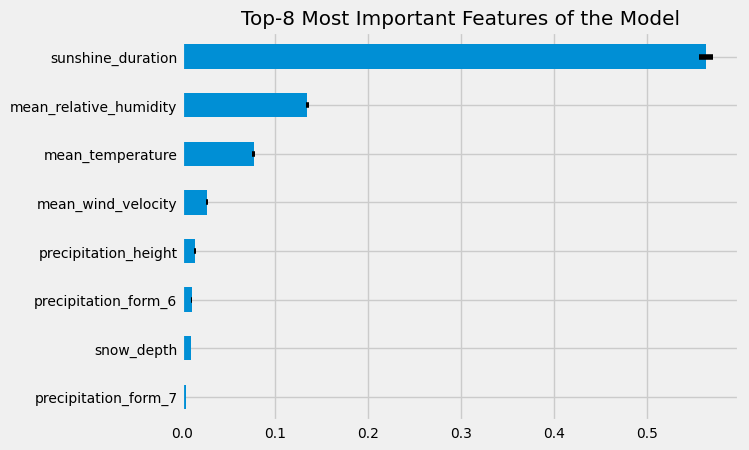

In [83]:
# !!!
# took ~45 s from a MacBook Pro 2023
# Output the importance of top features
compute_importance(model3, X3, y_test_g1, rseed=42, top=8)

### On Group 1 - XGBoost

In [63]:
y_test_g1_ = df_final_weather['group1_pv']
y_pred_g1_ = model4.predict(X3)

print(f"Mean Squared Error: {mean_squared_error(y_test_g1_, y_pred_g1_):.3f}")
print(f'R^2 Score: {r2_score(y_test_g1_, y_pred_g1_):.3f}')

Mean Squared Error: 0.011
R^2 Score: 0.887


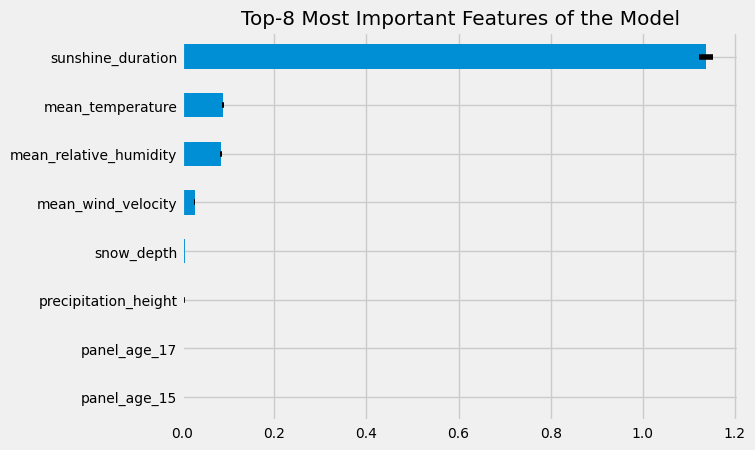

In [64]:
# took ~3 s from a MacBook Pro 2023
# Output the importance of top features
compute_importance(model4, X3, y_test_g1_, rseed=42, top=8)

### On Group 3 - RF

In [84]:
y_test_g3 = df_final_weather['group3_pv']
y_pred_g3 = model3.predict(X3)

print(f"Mean Squared Error: {mean_squared_error(y_test_g3, y_pred_g3):.3f}")
print(f'R^2 Score: {r2_score(y_test_g3, y_pred_g3):.3f}')

Mean Squared Error: 0.014
R^2 Score: 0.865


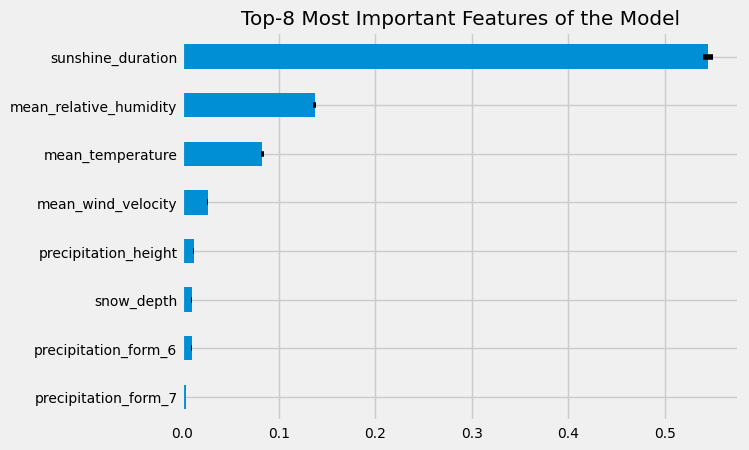

In [85]:
# !!!
# took ~45 s from a MacBook Pro 2023
# Output the importance of top features
compute_importance(model3, X3, y_test_g3, rseed=42, top=8)

### On Group 3 - XGBoost

In [67]:
y_test_g3_ = df_final_weather['group3_pv']
y_pred_g3_ = model4.predict(X3)

print(f"Mean Squared Error: {mean_squared_error(y_test_g3_, y_pred_g3_):.3f}")
print(f'R^2 Score: {r2_score(y_test_g3_, y_pred_g3_):.3f}')

Mean Squared Error: 0.014
R^2 Score: 0.871


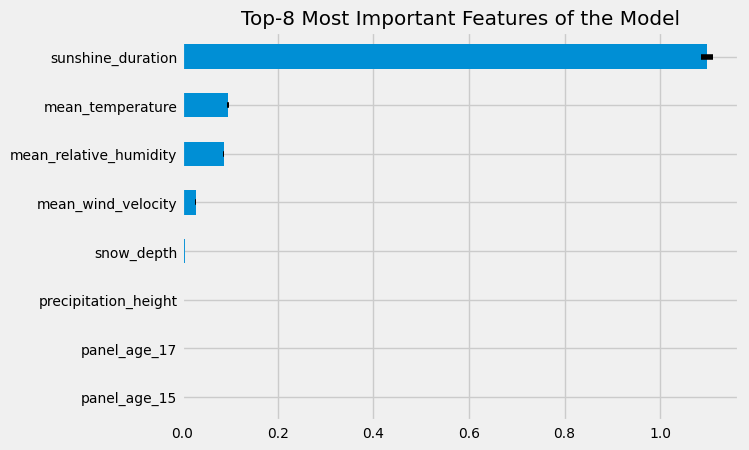

In [68]:
# took ~4 s from a MacBook Pro 2023
# Output the importance of top features
compute_importance(model4, X3, y_test_g3_, rseed=42, top=8)

## Summary

In [68]:
summary = pd.DataFrame({
    'Algorithm': ['Random Forest', 'Random Forest', 'Random Forest', 'Random Forest', 'XGBoost', 'XGBoost', 'XGBoost', 'XGBoost'],
    'Model': ['model3', 'model3', 'model3', 'model3', 'model4', 'model4', 'model4', 'model4'],
    'MSE': [0.002, 0.016, 0.007, 0.009, 0.010, 0.015, 0.011, 0.014],
    'R2': [0.979, 0.857, 0.93, 0.912, 0.909, 0.859, 0.887, 0.871],
    'Data Group': ['Group 2 - Train', 'Group 2 - Test', 'Group 1', 'Group  3', 'Group 2 - Train', 'Group 2 - Test', 'Group 1', 'Group  3']
})

summary

,Algorithm,Model,MSE,R2,Data Group
0,Random Forest,model3,0.002,0.979,Group 2 - Train
1,Random Forest,model3,0.016,0.857,Group 2 - Test
2,Random Forest,model3,0.007,0.930,Group 1
3,Random Forest,model3,0.009,0.912,Group 3
4,XGBoost,model4,0.010,0.909,Group 2 - Train
5,XGBoost,model4,0.015,0.859,Group 2 - Test
6,XGBoost,model4,0.011,0.887,Group 1
7,XGBoost,model4,0.014,0.871,Group 3


#### Train on Group 2

In [82]:
#

In [71]:
X_ = df_final_weather[['panel_age', "sunshine_duration", "precipitation_form", "precipitation_height", 
                       "mean_wind_velocity", "snow_depth", "mean_temperature", "mean_relative_humidity"]].copy()
X_ = pd.get_dummies(X_, columns=['panel_age', "precipitation_form"], drop_first=True)

def all_model_in_one(X, y, y_, r_seed, regression_algorithm, test_on_train=False):

    # Prepare
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=r_seed)
    #
    model =  None
    if regression_algorithm == "random_forest":
        model = RandomForestRegressor(n_estimators=500, random_state=r_seed, max_features='sqrt', max_depth=10,)
    elif regression_algorithm == "xg_boost":
        model = XGBRegressor(n_estimators=500, random_state=r_seed, use_label_encoder=False, eval_metric='rmse', max_depth=3,)
    else:
        print(f"the Algorithm {regression_algorithm!r} is not covered yet")
    
    # Fit the model
    model.fit(X_train, y_train)

    # Update the test set if necessary
    if not y.equals(y_):
        X_test = X
        y_test = y_
        # print(y_.name)
    
    if test_on_train:
        X_test = X_train
        y_test = y_train
    # Predict
    y_pred = model.predict(X_test)

    mse = f"{mean_squared_error(y_test, y_pred):.3f}"
    r2 = f"{r2_score(y_test, y_pred):.3f}"

    return mse, r2

    # print(f"Mean Squared Error: {mean_squared_error(y_test3, y_pred3):.3f}")
    # print(f'R^2 Score: {r2_score(y_test3, y_pred3):.3f}')

# r_seed = 100

model_dict = {
    1: (X_, 'group2_pv', "random_forest", True, 0, "Random Forest", "Group 2 - Train"), 
    2: (X_, 'group2_pv', "random_forest", False, 0, "Random Forest", "Group 2 - Test"),
    3: (X_, 'group1_pv', "random_forest", False, 1, "Random Forest", "Group 1"), 
    4: (X_, 'group3_pv', "random_forest", False, 1, "Random Forest", "Group 3"),
    5: (X_, 'group2_pv', "xg_boost", True, 0, "XGBoost", "Group 2 - Train"),
    6: (X_, 'group2_pv', "xg_boost", False, 0, "XGBoost", "Group 2 - Test"),
    7: (X_, 'group1_pv', "xg_boost", False, 1, "XGBoost", "Group 1"),
    8: (X_, 'group3_pv', "xg_boost", False, 1, "XGBoost", "Group 3"),
}


In [72]:
# !!!
# ~25 s
general_result = pd.DataFrame(columns=["r_seed","Algorithm","MSE","R2","Data Group"])

idx = 0

for r_seed in [42, 123, 325, 1785]:
    for _, val in model_dict.items():
        features, target_group, r_algorithm, test_on_train, test, algorithm_name, test_group = val
        
        # 
        X = features
        y = df_final_weather["group2_pv"]
        y_ = df_final_weather[target_group]

        # Train - Test - Get metrics
        mse, r2 = all_model_in_one(X, y, y_, r_seed, r_algorithm, test_on_train=test_on_train)

        # Add new row
        general_result.loc[idx] = [r_seed, algorithm_name, mse, r2, test_group]
        idx += 1

In [85]:
# general_result

In [73]:
# Define the desired order
order = ['Group 2 - Train', 'Group 2 - Test', 'Group 1', 'Group 3']

# Convert the 'Data Group' column to a categorical data type
general_result['Data Group'] = pd.Categorical(general_result['Data Group'], categories=order, ordered=True)

# Pivot for MSE
df_mse = general_result.pivot(index=['r_seed', 'Data Group'], columns='Algorithm', values='MSE').reset_index()
df_mse.columns = ['r_seed', 'Data Group', 'MSE_rf', 'MSE_xgb']

# Pivot for R2
df_r2 = general_result.pivot(index=['r_seed', 'Data Group'], columns='Algorithm', values='R2').reset_index()
df_r2.columns = ['r_seed', 'Data Group', 'R2_rf', 'R2_xgb']

# Merge both DataFrames
general_result2 = pd.merge(df_mse, df_r2, on=['r_seed', 'Data Group'])

general_result2

,r_seed,Data Group,MSE_rf,MSE_xgb,R2_rf,R2_xgb
0,42,Group 2 - Train,0.011,0.007,0.898,0.936
1,42,Group 2 - Test,0.017,0.017,0.841,0.840
2,42,Group 1,0.012,0.011,0.879,0.894
3,42,Group 3,0.014,0.013,0.864,0.878
4,123,Group 2 - Train,0.011,0.007,0.899,0.937
5,123,Group 2 - Test,0.018,0.019,0.834,0.821
6,123,Group 1,0.012,0.011,0.877,0.890
7,123,Group 3,0.015,0.013,0.862,0.873
8,325,Group 2 - Train,0.011,0.007,0.894,0.934
9,325,Group 2 - Test,0.016,0.017,0.855,0.850


#### Train on Group 2: single feature


In [74]:
X_ = df_final_weather[['panel_age', "sunshine_duration"]].copy()
X_ = pd.get_dummies(X_, columns=['panel_age'], drop_first=True)

def all_model_in_one(X, y, y_, r_seed, regression_algorithm, test_on_train=False):

    # Prepare
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=r_seed)
    #
    model =  None
    if regression_algorithm == "random_forest":
        model = RandomForestRegressor(n_estimators=500, random_state=r_seed, max_features='sqrt', max_depth=10,)
    elif regression_algorithm == "xg_boost":
        model = XGBRegressor(n_estimators=500, random_state=r_seed, use_label_encoder=False, eval_metric='rmse', max_depth=3,)
    else:
        print(f"the Algorithm {regression_algorithm!r} is not covered yet")
    
    # Fit the model
    model.fit(X_train, y_train)

    # Update the test set if necessary
    if not y.equals(y_):
        X_test = X
        y_test = y_
        # print(y_.name)
    
    if test_on_train:
        X_test = X_train
        y_test = y_train
    # Predict
    y_pred = model.predict(X_test)

    mse = f"{mean_squared_error(y_test, y_pred):.3f}"
    r2 = f"{r2_score(y_test, y_pred):.3f}"

    return mse, r2

    # print(f"Mean Squared Error: {mean_squared_error(y_test3, y_pred3):.3f}")
    # print(f'R^2 Score: {r2_score(y_test3, y_pred3):.3f}')

# r_seed = 100

model_dict = {
    1: (X_, 'group2_pv', "random_forest", True, 0, "Random Forest", "Group 2 - Train"), 
    2: (X_, 'group2_pv', "random_forest", False, 0, "Random Forest", "Group 2 - Test"),
    3: (X_, 'group1_pv', "random_forest", False, 1, "Random Forest", "Group 1"), 
    4: (X_, 'group3_pv', "random_forest", False, 1, "Random Forest", "Group 3"),
    5: (X_, 'group2_pv', "xg_boost", True, 0, "XGBoost", "Group 2 - Train"),
    6: (X_, 'group2_pv', "xg_boost", False, 0, "XGBoost", "Group 2 - Test"),
    7: (X_, 'group1_pv', "xg_boost", False, 1, "XGBoost", "Group 1"),
    8: (X_, 'group3_pv', "xg_boost", False, 1, "XGBoost", "Group 3"),
}

In [75]:
# !!!
# ~17 s
general_result = pd.DataFrame(columns=["r_seed","Algorithm","MSE","R2","Data Group"])

idx = 0

for r_seed in [42, 123, 325, 1785]:
    for _, val in model_dict.items():
        features, target_group, r_algorithm, test_on_train, test, algorithm_name, test_group = val
        
        # 
        X = features
        y = df_final_weather["group2_pv"]
        y_ = df_final_weather[target_group]

        # Train - Test - Get metrics
        mse, r2 = all_model_in_one(X, y, y_, r_seed, r_algorithm, test_on_train=test_on_train)

        # Add new row
        general_result.loc[idx] = [r_seed, algorithm_name, mse, r2, test_group]
        idx += 1

In [76]:
# Define the desired order
order = ['Group 2 - Train', 'Group 2 - Test', 'Group 1', 'Group 3']

# Convert the 'Data Group' column to a categorical data type
general_result['Data Group'] = pd.Categorical(general_result['Data Group'], categories=order, ordered=True)

# Pivot for MSE
df_mse = general_result.pivot(index=['r_seed', 'Data Group'], columns='Algorithm', values='MSE').reset_index()
df_mse.columns = ['r_seed', 'Data Group', 'MSE_rf', 'MSE_xgb']

# Pivot for R2
df_r2 = general_result.pivot(index=['r_seed', 'Data Group'], columns='Algorithm', values='R2').reset_index()
df_r2.columns = ['r_seed', 'Data Group', 'R2_rf', 'R2_xgb']

# Merge both DataFrames
general_result2 = pd.merge(df_mse, df_r2, on=['r_seed', 'Data Group'])

general_result2

,r_seed,Data Group,MSE_rf,MSE_xgb,R2_rf,R2_xgb
0,42,Group 2 - Train,0.019,0.015,0.822,0.856
1,42,Group 2 - Test,0.023,0.023,0.792,0.786
2,42,Group 1,0.019,0.017,0.813,0.828
3,42,Group 3,0.022,0.020,0.787,0.806
4,123,Group 2 - Train,0.019,0.016,0.824,0.856
5,123,Group 2 - Test,0.025,0.025,0.768,0.770
6,123,Group 1,0.019,0.018,0.807,0.823
7,123,Group 3,0.023,0.021,0.782,0.801
8,325,Group 2 - Train,0.020,0.016,0.816,0.852
9,325,Group 2 - Test,0.023,0.022,0.794,0.801
